# 02 · Общая аналитика гранат на Cache

Метрики — `src/metrics.py`.

**Исход гранаты** (одна строка = один бросок):
- флешка: `enemy_blind` / `team_blind` / `self_blind` — ослепления **> 1.5 с**; `flash_kill`, `team_flash_death`; `flash_result` — полезная / размен / вредная / пустая;
- HE и огонь: `enemy_dmg`, `enemy_kill`, `enemies_hit`;
- смок: исхода в данных нет.

**Контекст:** `pistol` (раунды 0 и 12), `sec_from_first`, `team_nades_nearby` (±5 с), `rating_tier`.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from metrics import load_throws, FLASH_RESULTS, RATING_LABELS
from mapviz import draw_density

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})

GRENADE_TYPES = ["smoke", "flash", "he", "fire"]

throws = load_throws()
flashes = throws[throws.type == "flash"]
hes = throws[throws.type == "he"]
molotovs = throws[throws.type == "fire"]
len(throws)

2385417

## 1. Сколько гранат кидают

type,smoke,flash,he,fire
side,,,,
CT,1.91,1.31,1.63,1.28
T,1.71,1.89,1.17,0.93


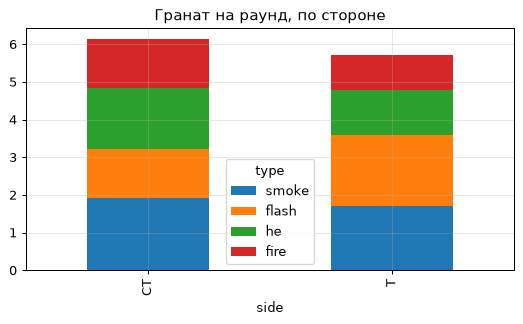

In [2]:
total_rounds = throws.groupby("match_id")["round"].nunique().sum()
per_round_by_side = (
    throws.groupby(["side", "type"], observed=True).size() / total_rounds
).unstack()[GRENADE_TYPES]

per_round_by_side.plot.bar(stacked=True, figsize=(7, 3.5), title="Гранат на раунд, по стороне")
per_round_by_side.round(2)

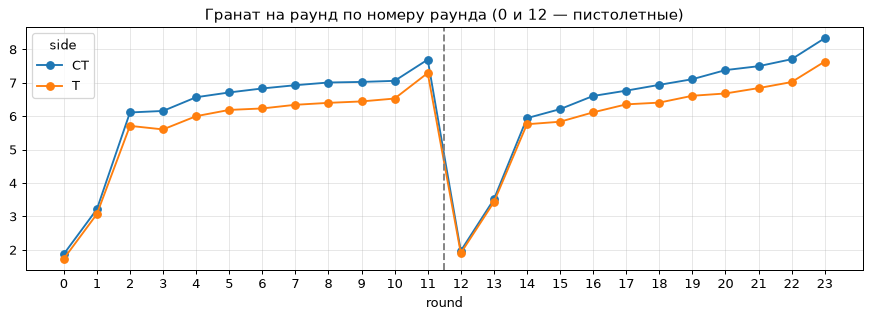

In [3]:
regular_half = throws[throws["round"] < 24]
matches_per_round = regular_half.groupby("round").match_id.nunique()
by_round_side = regular_half.groupby(["round", "side"], observed=True).size().unstack() / matches_per_round.values[:, None]

ax = by_round_side.plot(marker="o", figsize=(12, 3.5), title="Гранат на раунд по номеру раунда (0 и 12 — пистолетные)")
ax.axvline(11.5, color="gray", ls="--")
ax.set_xticks(range(24))

- В пистолетных раундах (0, 12) ~2 гранаты на сторону, в следующем раунде ~3, полноценный закуп — с раундов 2 и 14.
  Экономики в данных нет, но она видна косвенно.
- К концу половины гранат больше: копится оружие и деньги; в раунде 11 (последний перед сменой сторон) — пик, тратят всё.
- CT кидают больше смоков и HE, T — больше флешек.

## 2. Когда кидают

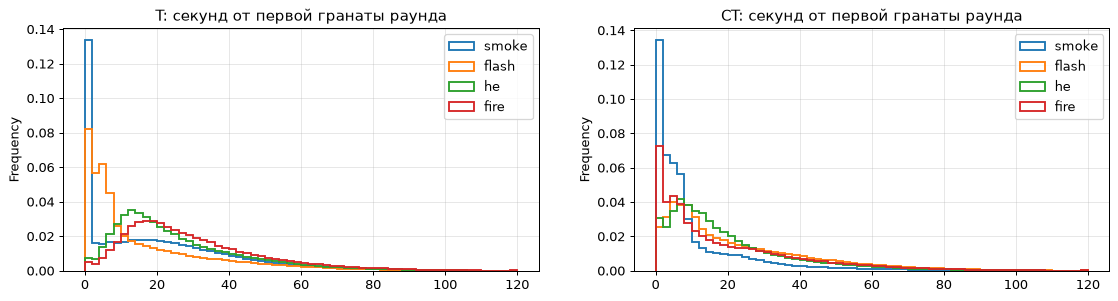

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3.5))
for ax, side in zip(axs, ["T", "CT"]):
    for grenade_type in GRENADE_TYPES:
        seconds = throws[(throws.side == side) & (throws.type == grenade_type)].sec_from_first.clip(upper=120)
        seconds.plot.hist(bins=60, histtype="step", lw=1.5, ax=ax, label=grenade_type, density=True)
    ax.set_title(f"{side}: секунд от первой гранаты раунда")
    ax.legend()

In [5]:
throws["push"] = pd.cut(
    throws.team_nades_nearby,
    [-1, 0, 2, 100],
    labels=["одиночная", "2-3 гранаты", "4+ гранат"],
)
throws.groupby(["side", "push"], observed=True).size().unstack().apply(lambda row: row / row.sum(), axis=1).round(2)

push,одиночная,2-3 гранаты,4+ гранат
side,,,
CT,0.23,0.45,0.33
T,0.29,0.51,0.20


Гранаты команды в окне ±5 с — признак скоординированного захода или ретейка.

## 3. Куда кидают: тепловые карты точек срабатывания

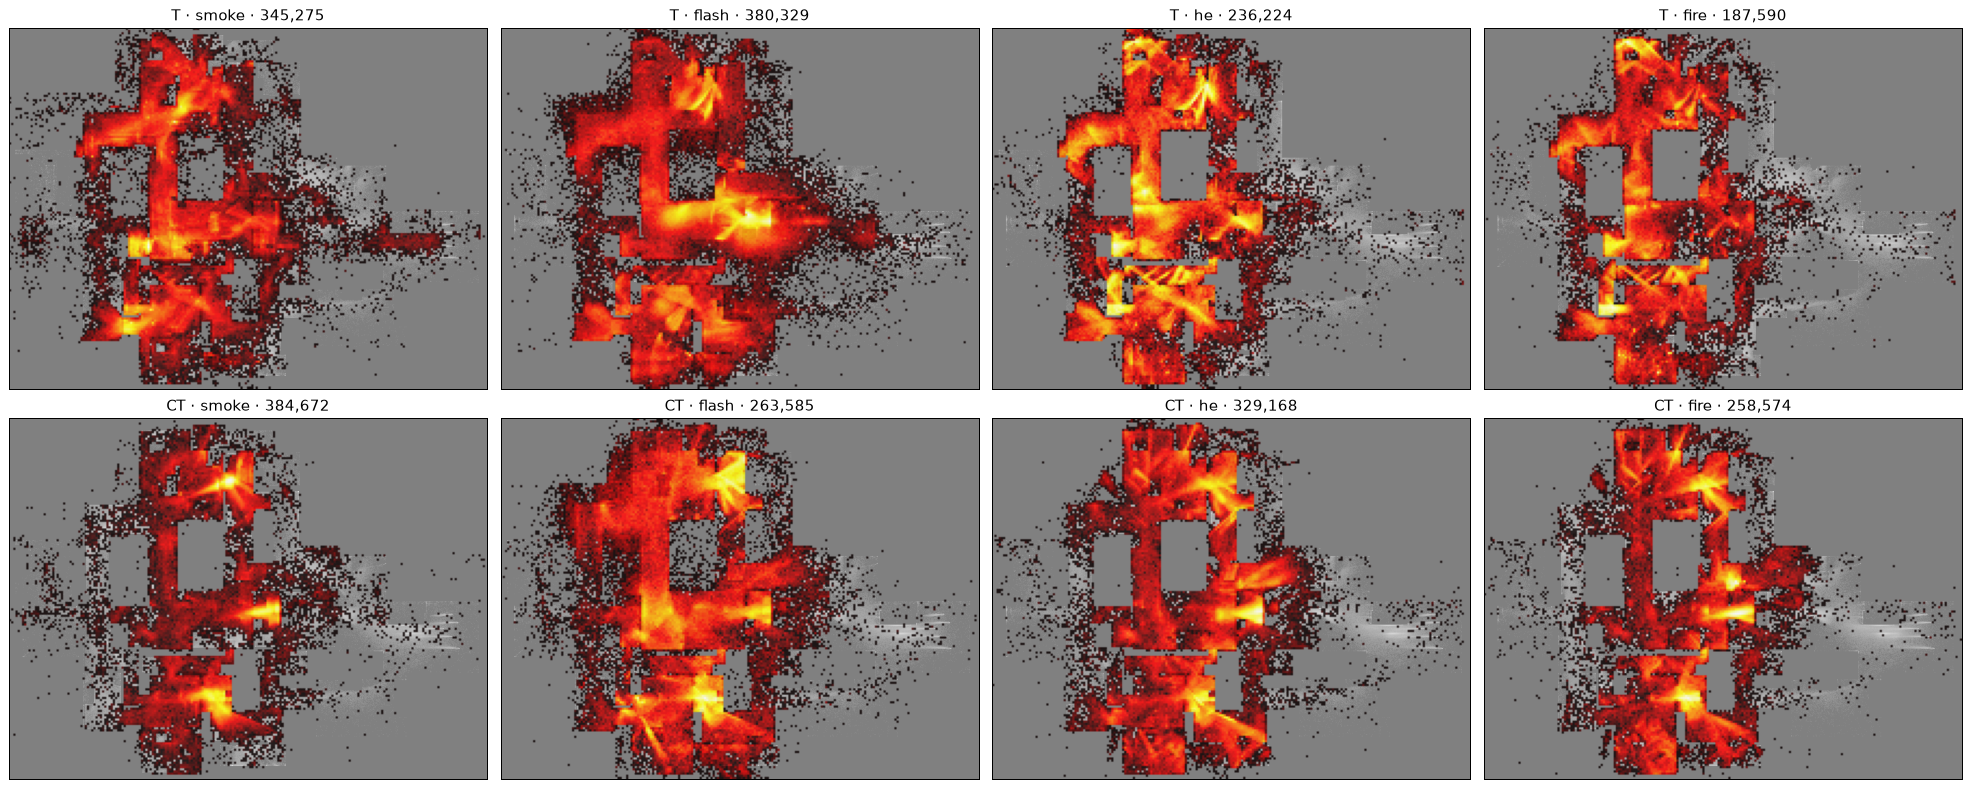

In [6]:
fig, axs = plt.subplots(2, 4, figsize=(22, 9))
for row, side in enumerate(["T", "CT"]):
    for col, grenade_type in enumerate(GRENADE_TYPES):
        subset = throws[(throws.side == side) & (throws.type == grenade_type)]
        draw_density(axs[row, col], subset.land_x, subset.land_y)
        axs[row, col].set_title(f"{side} · {grenade_type} · {len(subset):,}")
plt.tight_layout()

Яркие «точки» (особенно у смоков и молотовов CT) — это повторяющиеся раскидки: тысячи игроков кидают гранату в одно место.
Их и будем вытаскивать кластеризацией (ноутбук 03). Флешки размазаны сильнее — их кидают более ситуативно.

## 4. Флешки

flash_result,полезная,размен,вредная,пустая
side,,,,
CT,0.246,0.089,0.194,0.471
T,0.305,0.087,0.166,0.442


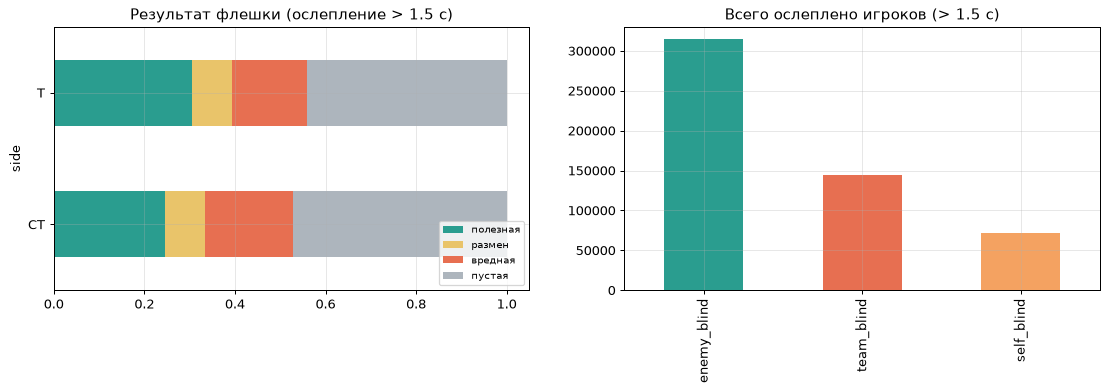

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3.8))
result_share = (
    flashes.groupby("side", observed=True).flash_result.value_counts(normalize=True).unstack()[FLASH_RESULTS]
)
result_share.plot.barh(
    stacked=True,
    ax=axs[0],
    title="Результат флешки (ослепление > 1.5 с)",
    color=["#2a9d8f", "#e9c46a", "#e76f51", "#adb5bd"],
)
axs[0].legend(loc="lower right", fontsize=8)
flashes[["enemy_blind", "team_blind", "self_blind"]].sum().plot.bar(
    ax=axs[1], title="Всего ослеплено игроков (> 1.5 с)", color=["#2a9d8f", "#e76f51", "#f4a261"]
)
result_share.round(3)

In [ ]:
pd.DataFrame(
    {
        "врагов ослеплено на флешку": flashes.enemy_blind.mean(),
        "своих+себя ослеплено на флешку": (flashes.team_blind + flashes.self_blind).mean(),
        "убийств по ослеплённым врагам на 100 флешек": flashes.flash_kill.mean() * 100,
        "смертей ослеплённых своих на 100 флешек": flashes.team_flash_death.mean() * 100,
    },
    index=["значение"],
).T.round(2)

,значение
врагов ослеплено на флешку,0.49
своих+себя ослеплено на флешку,0.34
убийств по ослеплённым врагам на 100 флешек,4.83
смертей ослеплённых своих на 100 флешек,2.68


In [ ]:
def flash_summary(group):
    return pd.DataFrame(
        {
            "n": group.size(),
            "полезная %": group.flash_result.eq("полезная").mean() * 100,
            "вредная %": group.flash_result.eq("вредная").mean() * 100,
            "пустая %": group.flash_result.eq("пустая").mean() * 100,
            "убийств /100": group.flash_kill.mean() * 100,
        }
    ).round(1)


display(flash_summary(flashes.groupby(["side", "push"], observed=True)))
display(flash_summary(flashes.groupby(["side", "pistol"], observed=True)))

n  полезная %  вредная %  пустая %  убийств /100
side push                                                              
CT   одиночная     74443        25.1       17.1      50.1           6.6
     2-3 гранаты  113845        25.2       19.3      46.0           5.7
     4+ гранат     75297        23.1       21.9      45.6           4.3
T    одиночная    100603        28.3       16.7      47.4           5.1
     2-3 гранаты  197652        30.8       16.6      43.9           4.3
     4+ гранат     82074        32.6       16.4      40.9           3.4

n  полезная %  вредная %  пустая %  убийств /100
side pistol                                                       
CT   False   259095        24.4       19.5      47.3           5.5
     True      4490        31.7       16.2      36.4          11.1
T    False   369011        30.5       16.5      44.4           4.2
     True     11318        31.9       17.5      36.5           6.7

На T-заходе (4+ гранат) флешки полезнее; на CT-ретейке — чаще вредные и пустые.

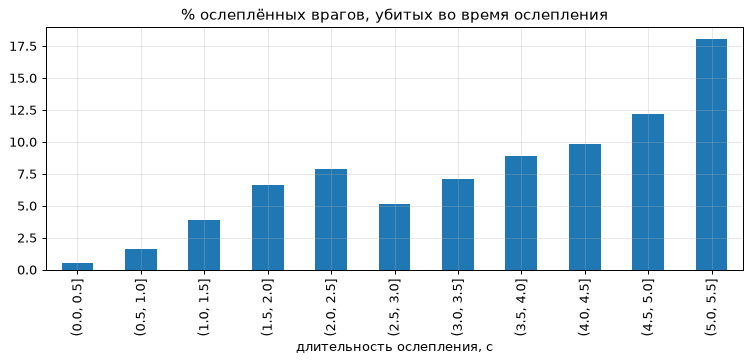

In [ ]:
flash_victims = pd.read_parquet("../data/flash_victims.parquet")
enemy_flashes = flash_victims[flash_victims.victim == "enemy"]

ax = (
    enemy_flashes.groupby(pd.cut(enemy_flashes.duration, np.arange(0, 6.1, 0.5)), observed=True)
    .killed.mean()
    .mul(100)
    .plot.bar(figsize=(10, 3.5), title="% ослеплённых врагов, убитых во время ослепления")
)
ax.set_xlabel("длительность ослепления, с")

Короткое ослепление (<1.5 с) почти не ведёт к убийству; от 1.5 с доля убийств растёт.

,HE,молотов
без урона %,63.3,86.5
средний урон,8.7,2.4
"урон, если попал",23.8,18.0
задето врагов (если попал),1.3,1.1
убийств на 100,2.4,0.9


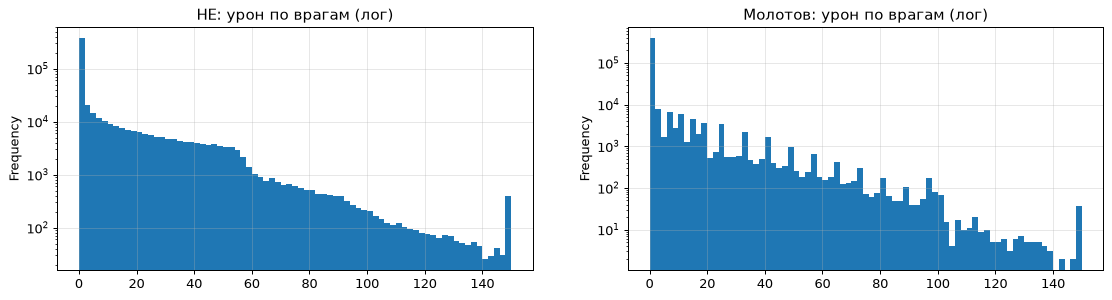

In [11]:
sec_bins = [-1, 5, 15, 30, 60, 1000]
sec_labels = ["0-5", "5-15", "15-30", "30-60", "60+"]

fig, axs = plt.subplots(1, 2, figsize=(15, 3.5))
for ax, (label, subset) in zip(axs, [("HE", hes), ("Молотов", molotovs)]):
    by_time = (
        subset.groupby([pd.cut(subset.sec_from_first, sec_bins, labels=sec_labels), "side"], observed=True)
        .enemy_dmg.mean()
        .unstack()
    )
    by_time.plot.bar(ax=ax, title=f"{label}: средний урон vs секунда от первой гранаты раунда")

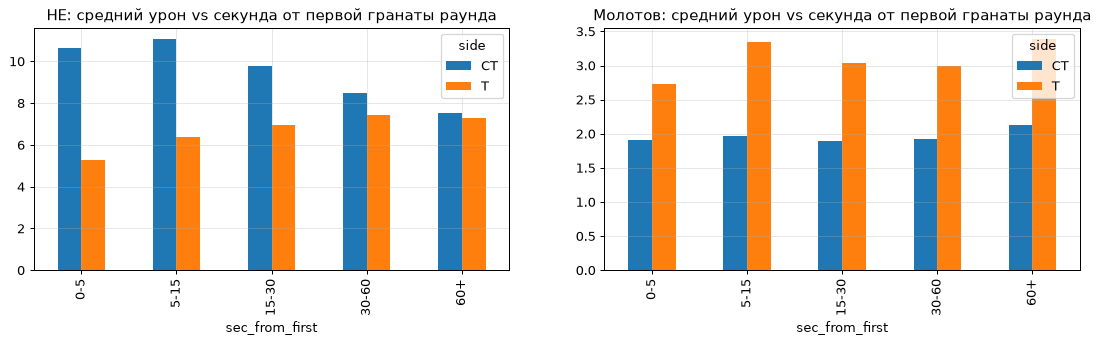

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3.5))
for ax, (name, g) in zip(axs, [("HE", he), ("Молотов", fire)]):
    t = g.groupby([pd.cut(g.sec_from_first, [-1, 5, 15, 30, 60, 1000], labels=["0-5", "5-15", "15-30", "30-60", "60+"]), "side"],
                  observed=True).enemy_dmg.mean().unstack()
    t.plot.bar(ax=ax, title=f"{name}: средний урон vs секунда от первой гранаты раунда")

- **HE у CT** самые результативные в начале раунда (~10–11 урона): встречают выход T. К концу раунда — 7–8.
- **HE у T** наоборот: в начале ~5 (кидают «на всякий случай»), к концу растёт до ~7.
- **Молотов** почти не зависит от времени; у T урон выше, чем у CT (CT чаще кидают молотов, чтобы перекрыть проход, а не нанести урон).

Одна и та же цифра урона значит разное в зависимости от стороны и момента → оценивать гранату нужно **относительно похожей ситуации**.

In [ ]:
rated = throws[throws.rating_tier.notna()]
rated_flashes = rated[rated.type == "flash"]
rated_hes = rated[rated.type == "he"]
rated_molotovs = rated[rated.type == "fire"]
rated_smokes = rated[rated.type == "smoke"]


def player_match_count(group):
    return group[["match_id", "thrower_id"]].drop_duplicates().shape[0]


by_tier = rated.groupby("rating_tier", observed=True)
rating_table = pd.DataFrame(
    {
        "игроков-матчей": by_tier.apply(player_match_count),
        "гранат за матч": by_tier.size() / by_tier.apply(player_match_count),
        "флешка: полезная %": rated_flashes.groupby("rating_tier", observed=True).flash_result.eq("полезная").mean() * 100,
        "флешка: вредная %": rated_flashes.groupby("rating_tier", observed=True).flash_result.eq("вредная").mean() * 100,
        "флешка: врагов ослеплено": rated_flashes.groupby("rating_tier", observed=True).enemy_blind.mean(),
        "HE: урон": rated_hes.groupby("rating_tier", observed=True).enemy_dmg.mean(),
        "молотов: урон": rated_molotovs.groupby("rating_tier", observed=True).enemy_dmg.mean(),
        "смок в прыжке %": rated_smokes.groupby("rating_tier", observed=True).airborne.mean() * 100,
    }
).round(2)
rating_table

In [13]:
plot_cols = ["флешка: полезная %", "флешка: вредная %", "HE: урон", "смок в прыжке %"]
rating_table[plot_cols].plot(
    subplots=True, layout=(1, 4), figsize=(20, 3.3), marker="o", legend=False, title=plot_cols, sharex=False
)

,игроков-матчей,гранат за матч,флешка: полезная %,флешка: вредная %,флешка: врагов ослеплено,HE: урон,молотов: урон,смок в прыжке %
rating_tier,,,,,,,,
<5k,2286,19.45,24.80,20.86,0.43,8.09,2.30,16.18
5-10k,3930,21.96,26.24,18.86,0.45,8.02,2.41,17.35
10-15k,6378,24.69,27.75,17.77,0.48,8.56,2.29,16.97
15-20k,6700,26.85,29.16,16.78,0.51,8.90,2.42,16.93
20-25k,3904,29.13,30.58,16.18,0.54,9.38,2.60,17.74
25k+,728,26.12,32.74,17.43,0.57,9.71,3.04,17.70


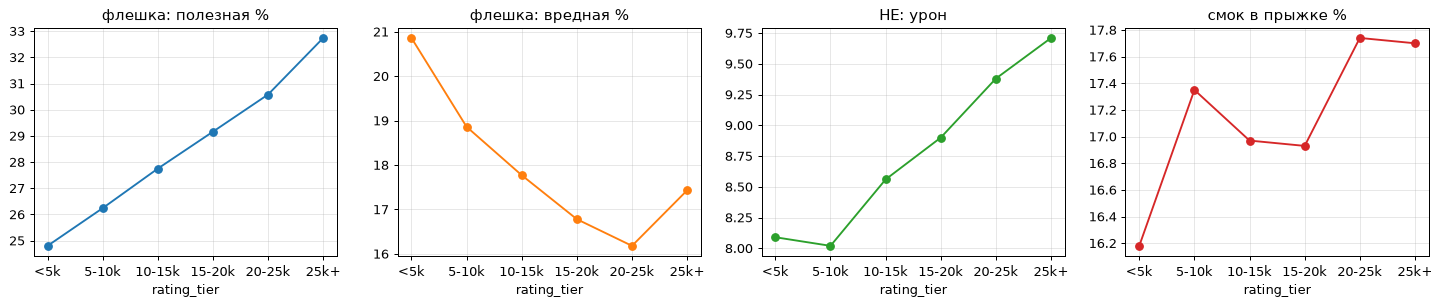

In [14]:
cols = ["флешка: полезная %", "флешка: вредная %", "HE: урон", "смок в прыжке %"]
tbl[cols].plot(subplots=True, layout=(1, 4), figsize=(20, 3.3), marker="o", legend=False, title=cols, sharex=False);

Тренды по рейтингу — справочно: рейтинг есть у ~¼ бросков, группы `<5k` и `25k+` маленькие.

## Выводы

1. **Флешки — главная зона роста.** 45% флешек никого не ослепили дольше 1.5 с, 18% ослепили только своих.
   На каждые 0.49 ослеплённых врагов приходится 0.34 ослеплённых своих.
2. **Порог 1.5 с оправдан:** врагов, ослеплённых меньше чем на 1.5 с, убивают в <4% случаев, дольше — в 7–18%.
3. **HE:** 63% без урона, но попавшая HE в среднем наносит ~24 урона. **Молотов:** 87% без урона — для него урон плохая цель
   (часто его кидают, чтобы перекрыть проход).
4. **Контекст меняет норму:** CT-HE в начале раунда и T-HE в конце — разные ситуации с разным ожидаемым уроном;
   на T заходе (4+ гранат) флешки полезнее, на CT ретейке — вреднее.
5. **Метрики связаны с уровнем игрока** — это главная проверка, что они осмысленны:
   от `<5k` к `25k+` доля полезных флешек растёт 25% → 33%, вредных падает 21% → 16–17%, урон HE 8.1 → 9.7,
   гранат за матч 19 → 26–29. Доля смоков в прыжке от рейтинга не зависит — значит, это свойство раскидок, а не навыка.